## Local setup (run once before the notebook)

From the project root in a terminal:

```bash
cd DeepfakeDetectionSystem
pip install -r requirements.txt
```

Copy `.env.example` to `.env` if you plan to use PostgreSQL. Place `data/dataset.csv` in the project, then open this notebook in VS Code, JupyterLab, or Jupyter Notebook.

---
## Step 1: Problem Definition
This project builds a Deepfake Detection application using PyTorch. We perform binary classification (REAL vs. FAKE) with explainability via Grad-CAM.

In [1]:
import os
import sys
from pathlib import Path

def find_project_root(marker: str = 'src') -> Path:
    """Locate project root whether the kernel cwd is the repo or notebooks/."""
    for start in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (start / marker).is_dir() and (start / 'requirements.txt').is_file():
            return start
    raise FileNotFoundError(
        'Could not find DeepfakeDetectionSystem root. '
        'Open this notebook from the project folder or run: cd DeepfakeDetectionSystem'
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Eagerly load the full PyTorch stack to avoid partial-import errors in notebooks.
import torch
import torch.optim
import torchvision

from src.model_builder import get_device

device = get_device()
print(f'Project root: {PROJECT_ROOT}')
print(f'Working directory: {Path.cwd()}')
print(f'Device: {device}')
if device.type == 'cpu':
    print('Training on CPU works but is slow. Use a CUDA GPU when available.')

Project root: C:\Users\jegad\projects\DeepfakeDetectionSystem
Working directory: C:\Users\jegad\projects\DeepfakeDetectionSystem
Device: cuda


## Step 2: Data Collection
Load metadata from PostgreSQL when available, otherwise ingest from `data/dataset.csv`.

In [2]:
from src.align_dataset import main as align_data
from src.data_ingestion import ingest_data

print('Aligning dataset (this will be fast if already aligned)...')
align_data()

df = ingest_data(force_rebuild=True)
if df is not None:
    display(df.head())
else:
    raise RuntimeError('Data ingestion failed. Add data/dataset.csv or configure PostgreSQL in .env.')

Checking if data is already ingested...


C:\Users\jegad\projects\DeepfakeDetectionSystem\src\data_ingestion.py:109: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


Data already exists! Found 5554 records in the database.


,id,image_id,label,gender,age_group,local_path
0,1,2,REAL,Male,50+,C:\Users\jegad\projects\DeepfakeDetectionSyste...
1,2,7,REAL,Male,26-35,C:\Users\jegad\projects\DeepfakeDetectionSyste...
2,3,10,REAL,Unknown,26-35,C:\Users\jegad\projects\DeepfakeDetectionSyste...
3,4,3,REAL,Female,36-50,C:\Users\jegad\projects\DeepfakeDetectionSyste...
4,5,5,REAL,Male,36-50,C:\Users\jegad\projects\DeepfakeDetectionSyste...


## Step 3: Data Cleaning
Drop rows with missing labels or image paths.

In [3]:
from src.data_preprocessing import clean_data

print('Missing values before cleaning:')
print(df.isnull().sum())
df = clean_data(df)
print(f'Records after cleaning: {len(df)}')

Missing values before cleaning:
id            0
image_id      0
label         0
gender        0
age_group     0
local_path    0
dtype: int64
Records after cleaning: 5554


## Step 4: Feature Engineering / Augmentation
PyTorch transforms with ImageNet normalization and light augmentation.

## Step 5: Train-Val-Test Split
70/10/20 stratified split via `get_dataloaders()` — `batch_size=8` for GTX 1650 Ti (4GB VRAM).

In [4]:
from src.data_preprocessing import get_dataloaders

BATCH_SIZE = 8
GRAD_ACCUM = 4  # effective batch size 32

train_loader, val_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)

print(f'Training set size: {len(train_loader.dataset)}')
print(f'Validation set size: {len(val_loader.dataset)}')
print(f'Test set size: {len(test_loader.dataset)}')
print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM}')

Training set size: 4443
Validation set size: 1111
DataLoader workers: 0


## Step 6: Model Selection
EfficientNet-B0 with frozen ImageNet backbone (classifier head only trains first).

In [5]:
from src.model_builder import build_efficientnet, set_backbone_trainable

ARCHITECTURE = 'EfficientNet'
model = build_efficientnet().to(device)
set_backbone_trainable(model, ARCHITECTURE, trainable=False)
print(f'{ARCHITECTURE} initialized on {device} (backbone frozen)')

Models initialized on cuda


## Step 7: Model Training
Train EfficientNet with early stopping, AMP, and gradient accumulation (`lr=1e-3`, up to 20 epochs).

In [6]:
from src.train_models import train_model

best_model, _ = train_model(
    model,
    train_loader,
    val_loader,
    ARCHITECTURE,
    device=device,
    epochs=20,
    patience=5,
    lr=1e-3,
    architecture=ARCHITECTURE,
    gradient_accumulation_steps=GRAD_ACCUM,
)


--- Starting training for EfficientNet with lr=0.0001 ---


Validation Epoch 1/5: 100%|██████████| 139/139 [00:27<00:00,  5.03it/s, loss=0.0141, acc=1.0000]


EfficientNet - Epoch 1/5 | Train Loss: 0.1161 | Train Acc: 0.9678 | Val Loss: 0.0205 | Val Acc: 0.9919


Validation Epoch 2/5: 100%|██████████| 139/139 [00:26<00:00,  5.21it/s, loss=0.0145, acc=1.0000]


EfficientNet - Epoch 2/5 | Train Loss: 0.0449 | Train Acc: 0.9854 | Val Loss: 0.0159 | Val Acc: 0.9955


...

ResNet - Epoch 3/5 | Train Loss: 0.0267 | Train Acc: 0.9932 | Val Loss: 0.0041 | Val Acc: 1.0000


Validation Epoch 4/5: 100%|██████████| 139/139 [00:42<00:00,  3.29it/s, loss=0.0006, acc=1.0000]


ResNet - Epoch 4/5 | Train Loss: 0.0201 | Train Acc: 0.9939 | Val Loss: 0.0139 | Val Acc: 0.9946


Validation Epoch 5/5: 100%|██████████| 139/139 [00:42<00:00,  3.27it/s, loss=0.0003, acc=1.0000]

ResNet - Epoch 5/5 | Train Loss: 0.0159 | Train Acc: 0.9962 | Val Loss: 0.0109 | Val Acc: 0.9982
Training complete in 38m 39s


## Step 8: Model Evaluation
Confusion matrix, classification report, and ROC-AUC on validation and held-out test sets.


--- Evaluation Results for EfficientNet ---
Confusion Matrix:
 [[557   1]
 [  2 551]]

Classification Report:
               precision    recall  f1-score   support

        REAL       1.00      1.00      1.00       558
        FAKE       1.00      1.00      1.00       553

    accuracy                           1.00      1111
   macro avg       1.00      1.00      1.00      1111
weighted avg       1.00      1.00      1.00      1111

ROC-AUC Score: 1.0000


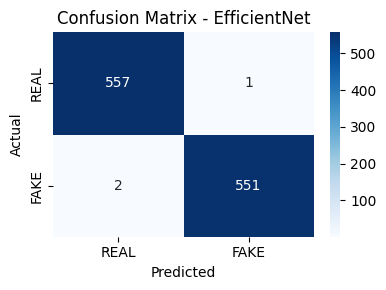


--- Evaluation Results for ResNet ---
Confusion Matrix:
 [[558   0]
 [  0 553]]

Classification Report:
               precision    recall  f1-score   support

        REAL       1.00      1.00      1.00       558
        FAKE       1.00      1.00      1.00       553

    accuracy                           1.00      1111
   macro avg       1.00      1.00      1.00      1111
weighted avg       1.00      1.00      1.00      1111

ROC-AUC Score: 1.0000


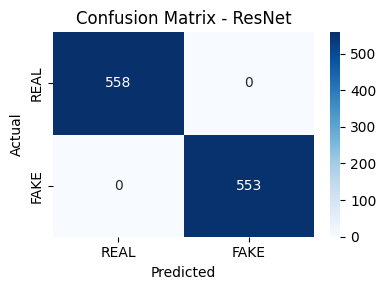

=> Dynamically Selected Best Model: ResNet


In [7]:
from src.evaluation import evaluate_model

evaluate_model(best_model, val_loader, f'{ARCHITECTURE} (val)', device=device)
evaluate_model(best_model, test_loader, f'{ARCHITECTURE} (test)', device=device)

## Step 9: Inference Smoke Test
Verify inference preprocessing matches training (full image, no face crop) before Streamlit demo.


--- Starting training for ResNet-Tuned with lr=5e-05 ---


Validation Epoch 1/2: 100%|██████████| 139/139 [00:41<00:00,  3.32it/s, loss=0.0005, acc=1.0000]


ResNet-Tuned - Epoch 1/2 | Train Loss: 0.0134 | Train Acc: 0.9962 | Val Loss: 0.0074 | Val Acc: 0.9991


Validation Epoch 2/2: 100%|██████████| 139/139 [00:41<00:00,  3.36it/s, loss=0.0005, acc=1.0000]


ResNet-Tuned - Epoch 2/2 | Train Loss: 0.0096 | Train Acc: 0.9973 | Val Loss: 0.0078 | Val Acc: 0.9973
Training complete in 14m 39s

--- Evaluation Results for ResNet-Tuned ---
Confusion Matrix:
 [[557   1]
 [  0 553]]

Classification Report:
               precision    recall  f1-score   support

        REAL       1.00      1.00      1.00       558
        FAKE       1.00      1.00      1.00       553

    accuracy                           1.00      1111
   macro avg       1.00      1.00      1.00      1111
weighted avg       1.00      1.00      1.00      1111

ROC-AUC Score: 1.0000


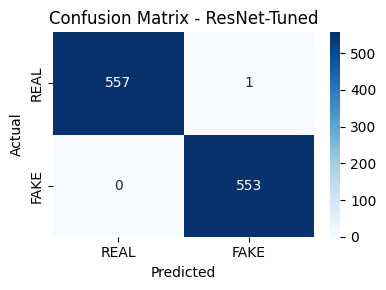

np.float64(0.9999967592862652)

In [8]:
import torch
from PIL import Image
from src.data_ingestion import resolve_image_path
from src.explainability import preprocess_for_inference_v2

best_model.eval()
samples = test_loader.dataset.dataframe.sample(6, random_state=42)

for _, row in samples.iterrows():
    img = Image.open(resolve_image_path(row['local_path'])).convert('RGB')
    tensor, _ = preprocess_for_inference_v2(img, device)
    with torch.no_grad():
        prob = torch.sigmoid(best_model(tensor).squeeze(1)).item()
    pred = 'FAKE' if prob > 0.5 else 'REAL'
    actual = row['label']
    ok = 'OK' if pred == actual else 'MISMATCH'
    print(f'{ok} actual={actual} pred={pred} prob={prob:.3f} path={row["local_path"]}')

## Step 10: Deployment
Save checkpoint with architecture metadata for the Streamlit app.

In [9]:
from src.model_loader import save_checkpoint

save_path = save_checkpoint(best_model, ARCHITECTURE)
print(f'Model saved to {save_path}')
print('Run the Streamlit app from the project root: streamlit run app/app.py')

Model saved to C:\Users\jegad\projects\DeepfakeDetectionSystem\models\final_deepfake_detector.pth
Run the Streamlit app from the project root: streamlit run app/app.py
